**EXERCISE 4**

In [ ]:
# Task 1
import numpy as np

five_d_matrix = np.ones((5, 5))

print(five_d_matrix)
print()

five_d_matrix[1:4, 1:4] = 0

print(five_d_matrix)







[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [ ]:

# Task 2
import numpy as np

np.random.seed(42)
random_data = np.random.randn(100, 3)
print(random_data)

data_mean = np.mean(random_data, axis = 0)

normalized_array = (random_data - data_mean) / np.std(random_data, axis = 0)

print()
print(normalized_array)




[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733]
 [-0.90802408 -1.4123037   1.46564877]
 [-0.2257763   0.0675282  -1.42474819]
 [-0.54438272  0.11092259 -1.15099358]
 [ 0.37569802 -0.60063869 -0.29169375]
 [-0.60170661  1.85227818 -0.01349722]
 [-1.05771093  0.82254491 -1.22084365]
 [ 0.2088636  -1.95967012 -1.32818605]
 [ 0.19686124  0.73846658  0.17136828]
 [-0.11564828 -0.3011037  -1.47852199]
 [-0.71984421 -0.46063877  1.05712223]
 [ 0.34361829 -1.76304016  0.32408397]
 [-0.38508228 -0.676922    0.61167629]
 [ 1.03099952  0.93128012 -0.83921752]
 [-0.30921238  0.33126343  0.97554513]
 [-0.47917424 -0.18565898 -1.10633497]
 [-1.19620662  0.81252582  1.35624003]
 [-0.07201012  1.0035329   0.36163603]
 [-0.64511975  0.36139561  1.53803657]
 [-0.03582604  1.56464366 -2.6197451 ]
 [ 0.8219025   0.08704707

In [ ]:
# Task 3
import numpy as np
from numpy.linalg import inv
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = (inv(np.transpose(X) @ X))  @ np.transpose(X) @ y

print("Estimated coeffecients: ")
print(theta_hat)
print()

print("True Theta: ")
print(true_theta)
print()

print("Difference")
difference = true_theta - theta_hat
print(difference)


Estimated coeffecients: 
[ 2.46816199 -1.19432451  3.70461987]

True Theta: 
[ 2.5 -1.2  3.7]

Difference
[ 0.03183801 -0.00567549 -0.00461987]


**`EXERCISE 5`**

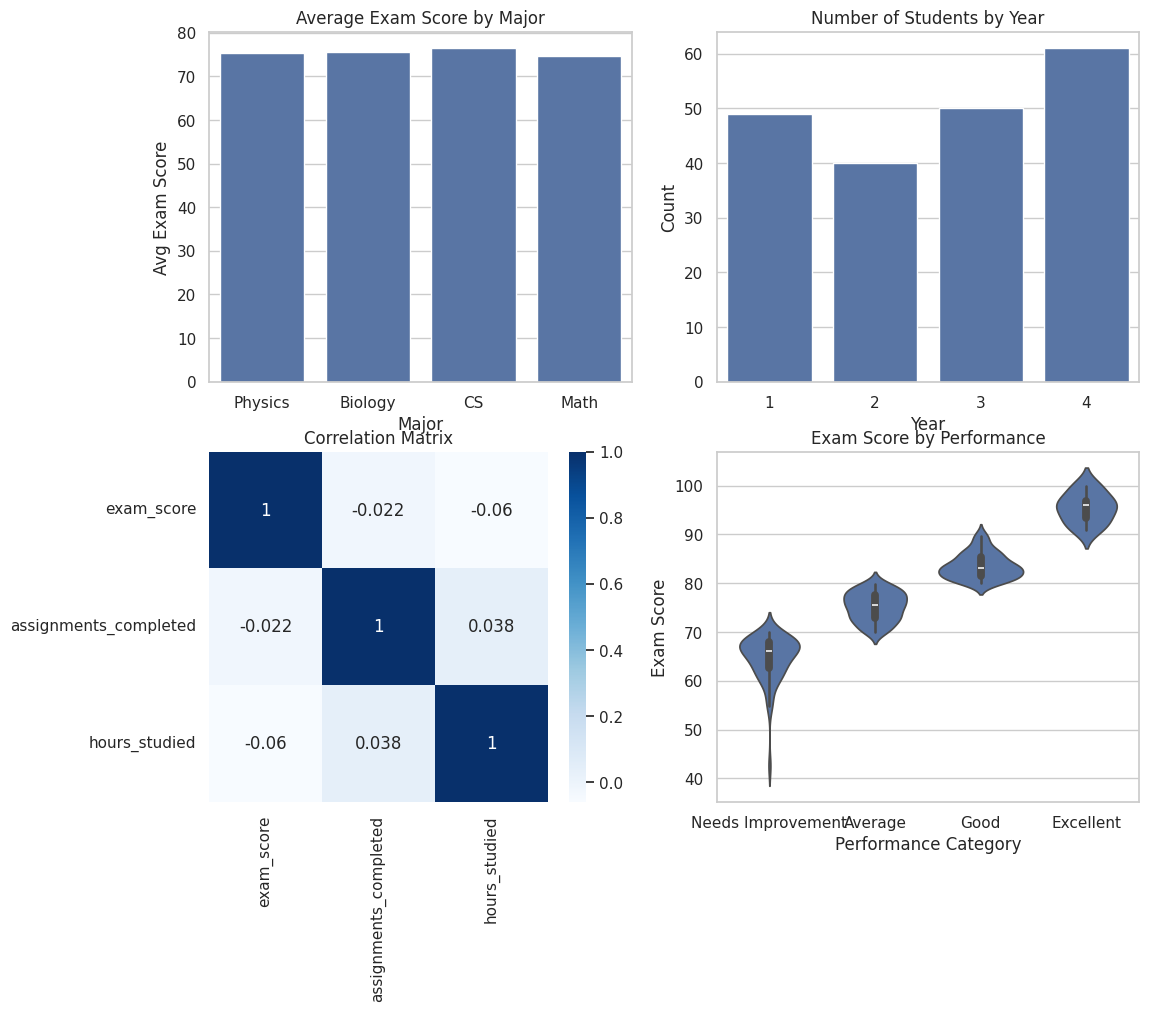

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introducing some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

#  TASK 1

print("DATASET INFORMATION:")
print(df.info())
print()

na_count = df.isna().sum()
print(print(na_count))
print()

exam_scores = df['exam_score']
exam_scores.fillna(exam_scores.mean())

hours_studied = df['hours_studied']
hours_studied.fillna(hours_studied.median())


#  TASK 2
major_scores = df.groupby('major').agg('exam_score')
major_scores_average = major_scores.mean().sort_values(ascending=False)
highest_major = major_scores_average.index[0]

print("Highest Major: " + highest_major)




hours_stud = df['hours_studied']
exam_scr = df['exam_score']
correlation = hours_stud.corr(exam_scr)
print("Correlation Value: " + str(correlation))




score_bins = [0, 70, 80, 90, 100]
performance_labels = ['Needs Improvement', 'Average', 'Good', 'Excellent']


df['performance'] = pd.cut(df['exam_score'], bins=score_bins, labels=performance_labels)



## Task 3
aggregated_data = df.groupby(['major', 'year']).agg({
    'student_id': 'count',
    'exam_score': 'mean',
    'hours_studied': 'mean'
})

top_5_students = df.nlargest(5, 'exam_score', keep='all')

print(top_5_students[['student_id', 'major', 'exam_score']])


pivot_table = df.pivot_table(
    index='major',
    columns='year',
    values='exam_score',
    aggfunc='mean'
)

print(pivot_table)



## EXERCISE 6

## Task 1
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='exam_score', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')


sns.boxplot(data=df, x='major', y='exam_score', palette='Set2', ax=axes[1])
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')


plt.suptitle('Student Performance Distribution', fontsize=14, fontweight='bold')

plt.show()


## Task 2
import matplotlib.pyplot as plt
import seaborn as sns


sns.lmplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    scatter_kws={'alpha': 0.7}
)


plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')

plt.show()


## Task 3
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Bar chart: Average exam score by major (Top-Left slot: 0, 0)
sns.barplot(data=df, x='major', y='exam_score', errorbar=None, ax=axes[0, 0])
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Avg Exam Score')

# 2. Count plot: Number of students by year (Top-Right slot: 0, 1)
sns.countplot(data=df, x='year', ax=axes[0, 1])
axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

# 3. Heat map: Correlation matrix of numerical columns (Bottom-Left slot: 1, 0)
# We select only the numeric columns first so the math doesn't break on text columns
numerical_columns = df[['exam_score', 'assignments_completed', 'hours_studied']]
corr_matrix = numerical_columns.corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot: Exam score distribution by performance category (Bottom-Right slot: 1, 1)
sns.violinplot(data=df, x='performance', y='exam_score', ax=axes[1, 1])
axes[1, 1].set_title('Exam Score by Performance')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')



# Display the dashboard
plt.show()



Exercise 7

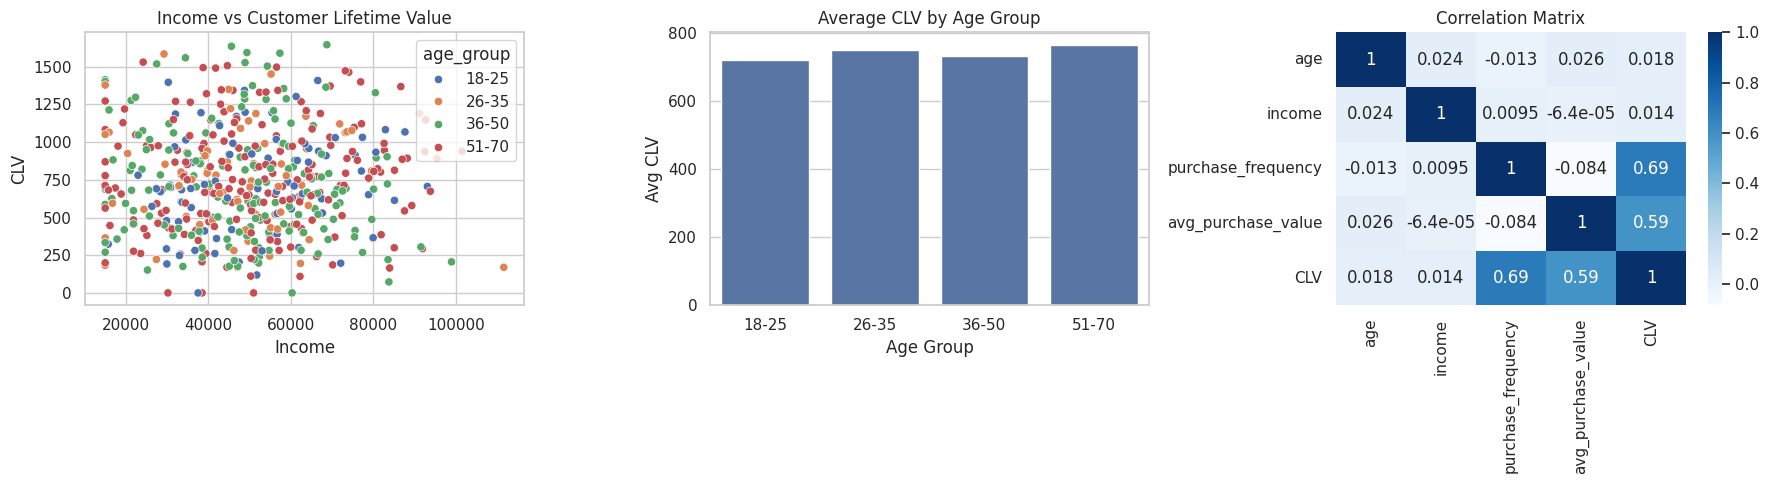

In [18]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


#Task 1
# 1. Find the maximum purchase frequency in the dataset
max_freq = customers['purchase_frequency'].max()

# 2. Calculate churn risk using the formula provided
churn_risk = 1 - (customers['purchase_frequency'] / max_freq)

# 3. Calculate Customer Lifetime Value (CLV) and save it as a new column
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + churn_risk)

# Define the boundary edges for the age groups
age_bins = [17, 25, 35, 50, 70]

# Define the text labels that match those buckets
age_labels = ['18-25', '26-35', '36-50', '51-70']

# Create the new age_group column
customers['age_group'] = pd.cut(customers['age'], bins=age_bins, labels=age_labels)




# Group by age_group and calculate all 4 required statistics at once
age_group_analysis = customers.groupby('age_group').agg({
    'age': 'count',         # Number of customers
    'income': 'mean',       # Average income
    'CLV': ['mean', 'sum']   # Average CLV AND Total CLV
})

# Flattening the column names so the table is easy to read and work with
age_group_analysis.columns = ['num_customers', 'avg_income', 'avg_clv', 'total_clv']

print(age_group_analysis)




clv_threshold = customers['CLV'].quantile(0.90)

# Filtering the dataset to get only customers above that threshold
top_10_percent_customers = customers[customers['CLV'] >= clv_threshold]

# Optional: Sort them from highest to lowest so it looks clean
top_10_percent_customers = top_10_percent_customers.sort_values(by='CLV', ascending=False)

print(f"Number of top tier customers found: {len(top_10_percent_customers)}")
print(top_10_percent_customers[['age', 'income', 'CLV']].head())




# VISUALIZATION

# Create a figure canvas with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter plot of income vs CLV (color by age group) -> Slot 1
# Using scatterplot allows us to use the 'hue' parameter for grouping
sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group',
    ax=axes[0]
)
axes[0].set_title('Income vs Customer Lifetime Value')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('CLV')

# 2. Bar chart of average CLV by age group -> Slot 2
# errorbar=None keeps the bars clean without extra metric lines
sns.barplot(
    data=customers,
    x='age_group',
    y='CLV',
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Avg CLV')

# 3. Correlation heatmap -> Slot 3
# We select only the number columns so text columns don't crash the calculation
numerical_cols = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']]
corr_matrix = numerical_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', ax=axes[2])
axes[2].set_title('Correlation Matrix')

# Clean up layout spacing and draw the dashboard
plt.tight_layout()
plt.show()

**Observations:**
1. There seems to not be a strong relationship between CLV and customer income.


2. There is a a strong relationship between how often a customer buys and their lifetime value. Customers who buy frequently have a low churn risk which increases their overall value to the company.

**Recommendations**

The company should not waste revenue on marketing for new customers but rather focus on maintaining relationships with customers.